In [2]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Бібліотеки завантажено")

✅ Бібліотеки завантажено


In [6]:
heart_disease = fetch_ucirepo(id=45)
df = heart_disease.data.original

df_clean = df.copy()
df_clean['target'] = df_clean.iloc[:, -1]

df_clean['ca'].fillna(0, inplace=True)
df_clean['thal'].fillna(df_clean['thal'].mode()[0], inplace=True)

print(f"Розмір даних: {df_clean.shape}")
print(f"Пропуски після очищення: {df_clean.isnull().sum().sum()}")
df_clean.head()

Розмір даних: (303, 15)
Пропуски після очищення: 0


/tmp/ipykernel_3964/2600655814.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['ca'].fillna(0, inplace=True)
/tmp/ipykernel_3964/2600655814.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


In [7]:
bins = [29, 40, 50, 60, 70, 80]
labels = ['29-40', '41-50', '51-60', '61-70', '71-80']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

print("Вікові групи додано")
df_clean[['age', 'age_group']].head()

Вікові групи додано


,age,age_group
0,63,61-70
1,67,61-70
2,67,61-70
3,37,29-40
4,41,41-50


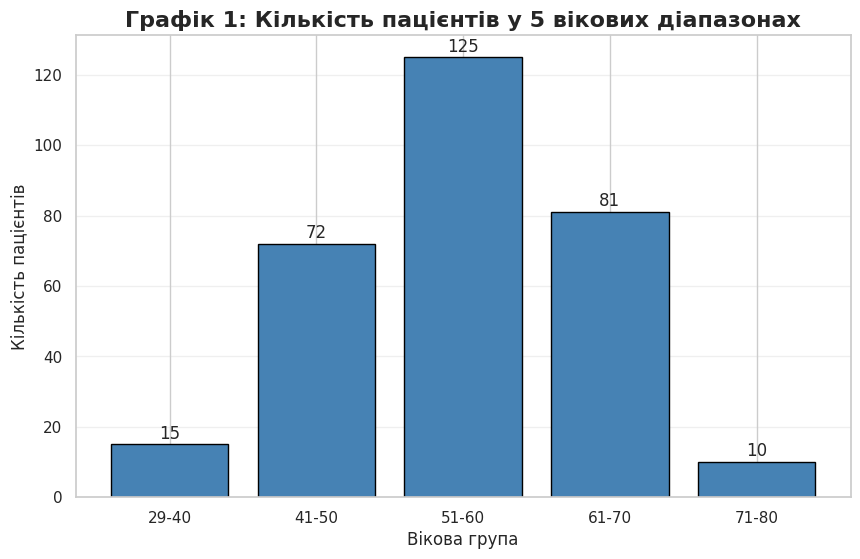

In [8]:
# Залежність максимального пульсу (thalach) від холестерину (chol)
plt.figure(figsize=(10, 6))
counts = df_clean['age_group'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

plt.title('Графік 1: Кількість пацієнтів у 5 вікових діапазонах', fontsize=16, fontweight='bold')
plt.xlabel('Вікова група', fontsize=12)
plt.ylabel('Кількість пацієнтів', fontsize=12)

for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(value), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()

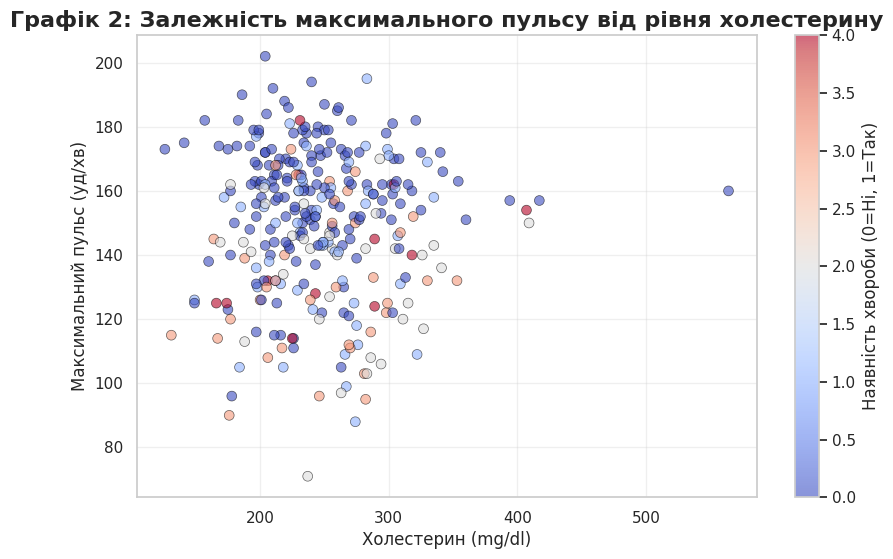

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['chol'], df_clean['thalach'],
                     c=df_clean['target'], cmap='coolwarm',
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Наявність хвороби (0=Ні, 1=Так)')

plt.title('Графік 2: Залежність максимального пульсу від рівня холестерину', fontsize=16, fontweight='bold')
plt.xlabel('Холестерин (mg/dl)', fontsize=12)
plt.ylabel('Максимальний пульс (уд/хв)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_3964/2589777256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cp', y='thalach', palette='Set2')


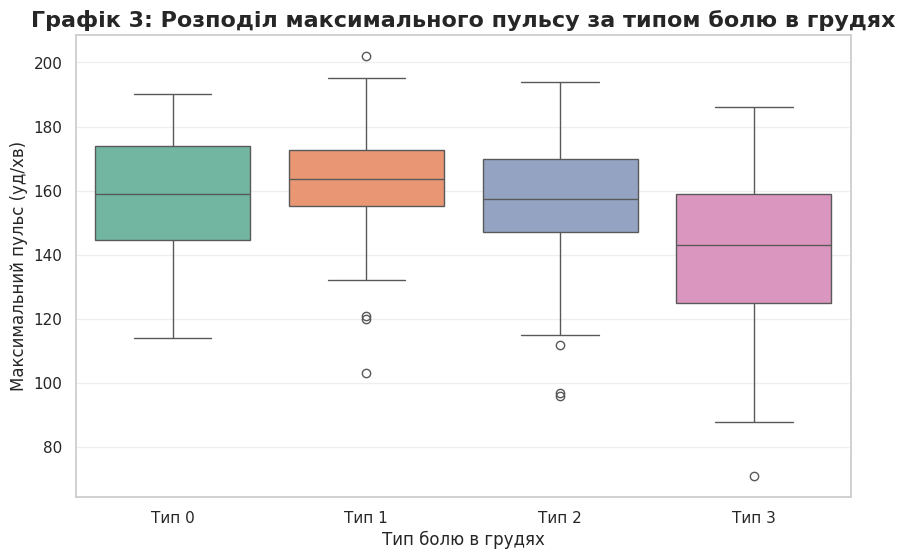

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='cp', y='thalach', palette='Set2')

plt.title('Графік 3: Розподіл максимального пульсу за типом болю в грудях', fontsize=16, fontweight='bold')
plt.xlabel('Тип болю в грудях', fontsize=12)
plt.ylabel('Максимальний пульс (уд/хв)', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Тип 0', 'Тип 1', 'Тип 2', 'Тип 3'])
plt.grid(axis='y', alpha=0.3)
plt.show()

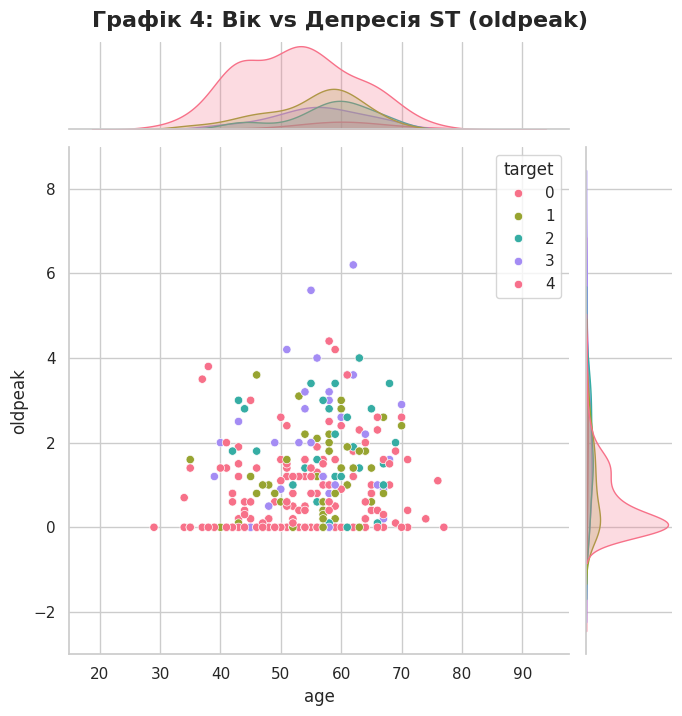

In [15]:
g = sns.jointplot(data=df_clean, x='age', y='oldpeak',
                  kind='scatter', hue='target',
                  palette='husl', height=7)
g.fig.suptitle('Графік 4: Вік vs Депресія ST (oldpeak)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

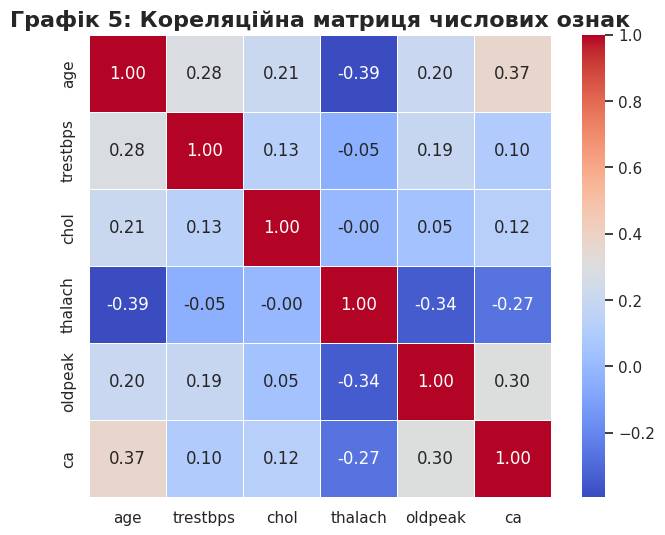

In [12]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Графік 5: Кореляційна матриця числових ознак', fontsize=16, fontweight='bold')
plt.show()

/tmp/ipykernel_3964/453103119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='target', y='chol', palette='muted')


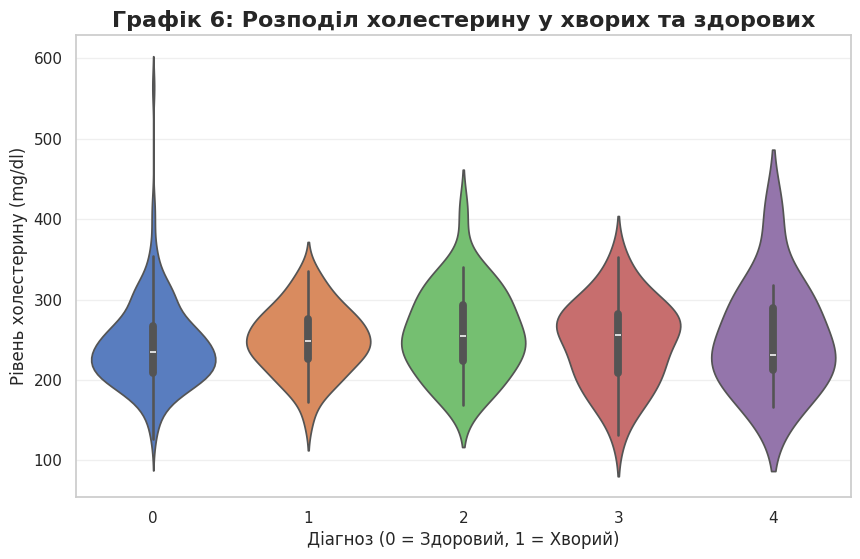

In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='target', y='chol', palette='muted')

plt.title('Графік 6: Розподіл холестерину у хворих та здорових', fontsize=16, fontweight='bold')
plt.xlabel('Діагноз (0 = Здоровий, 1 = Хворий)', fontsize=12)
plt.ylabel('Рівень холестерину (mg/dl)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

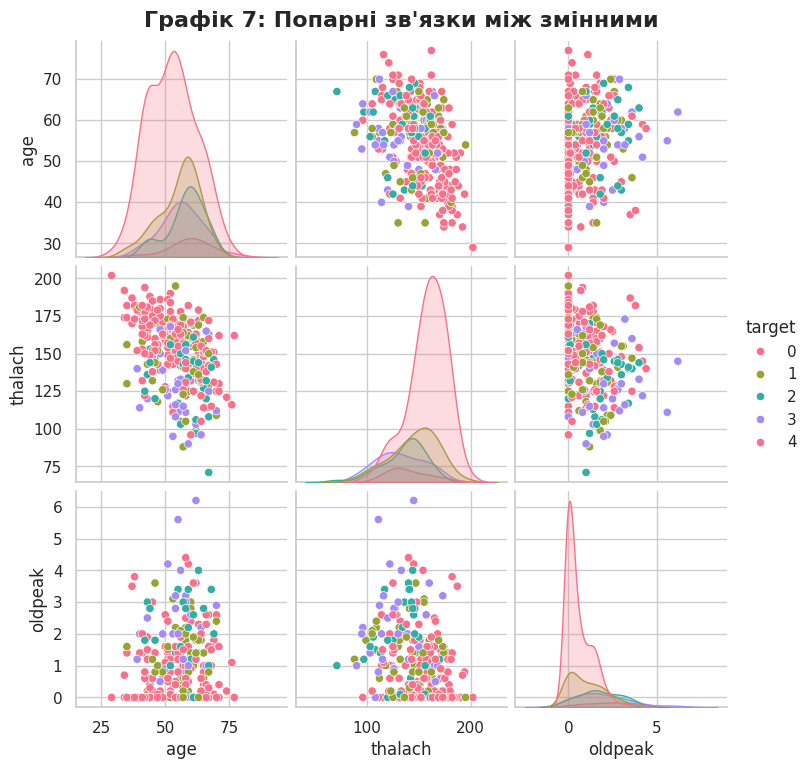

In [14]:
pairplot_data = df_clean[['age', 'thalach', 'oldpeak', 'target']]
sns.pairplot(pairplot_data, hue='target', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Графік 7: Попарні зв\'язки між змінними', y=1.02, fontsize=16, fontweight='bold')
plt.show()